# EDA

Goal of this notebook: comprehend the census bureau data before feature engineering and modeling details.

Major sections:
1. Data inspection and loading
   1. Data type determination
   2. Class imbalance inspection
   3. Feature distribution inspection
2. Main EDA steps
   1. Missing/"Not in Universe" value analysis
   2. Feature-target relationship exploration
   3. Feature correlation analysis

Refer to Reports.pdf and decisions.md for detailed findings and decision making process.

In [23]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Set display parameters for readability and efficiency
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# Set directory variables
DATA_DIR = Path("../data")              
DATA = DATA_DIR / "census-bureau.data"
COLS = DATA_DIR / "census-bureau.columns"

# Set seeds for re-producibility
SEED = 42

### 1. Data inspection and loading

This section examines the dataset size, column and sample rows to have an initial understanding. Then read the dataset as .csv

In [6]:
# Inspect column names and the first row
print("---")
print(COLS.read_text())
print("---")
with open(DATA) as f:
    first = f.readline()
print("fields in row 1:", len(first.split(",")))
print("first line repr:", repr(first))
with open(DATA) as f:
    n_rows = sum(1 for _ in f)
print("rows:", n_rows)

---
age
class of worker
detailed industry recode
detailed occupation recode
education
wage per hour
enroll in edu inst last wk
marital stat
major industry code
major occupation code
race
hispanic origin
sex
member of a labor union
reason for unemployment
full or part time employment stat
capital gains
capital losses
dividends from stocks
tax filer stat
region of previous residence
state of previous residence
detailed household and family stat
detailed household summary in household
weight
migration code-change in msa
migration code-change in reg
migration code-move within reg
live in this house 1 year ago
migration prev res in sunbelt
num persons worked for employer
family members under 18
country of birth father
country of birth mother
country of birth self
citizenship
own business or self employed
fill inc questionnaire for veteran's admin
veterans benefits
weeks worked in year
year
label

---
fields in row 1: 42
first line repr: '73,Not in universe,0,0,High school graduate,0,Not in 

In [7]:
# Read columns as a list, check for spelling and whitespaces
cols = [line.strip() for line in COLS.read_text().splitlines() if line.strip()]
print(len(cols), "columns")
print(cols)

42 columns
['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'we

In [ ]:
# Read data 
df = pd.read_csv(
    DATA,
    header=None,
    names=cols,
    skipinitialspace=True,
    dtype=str,                
)

# Strip any residual whitespace in string cells
for c in df.columns:
    df[c] = df[c].str.strip()

print(df.shape)
df.head()

(199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [9]:
# Determine numeric columns after the above inspection
numeric_cols = ["age", "wage per hour", "capital gains", "capital losses",
                "dividends from stocks", "num persons worked for employer",
                "weeks worked in year"]
weight_col   = "weight"   
label_col    = "label"       

for c in numeric_cols + [weight_col]:
    df[c] = pd.to_numeric(df[c], errors="raise")

print(df.dtypes.value_counts())
print('-' * 30)
print("label values:", df[label_col].value_counts())

object     34
int64       7
float64     1
Name: count, dtype: int64
------------------------------
label values: label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64


In [10]:
print("raw label values:", df[label_col].unique())
# Convert labels to 0-1 binary labels for classification
df["y"] = df[label_col].map({'- 50000.': 0, '50000+.': 1})

# Examine class imbalance
print("\nunweighted prevalence:", 100 * df["y"].mean().round(4), '%')
print("weighted prevalence:  ",
      (100.0 * (df["y"] * df[weight_col]).sum() / df[weight_col].sum()).round(4), '%')

raw label values: ['- 50000.' '50000+.']

unweighted prevalence: 6.21 %
weighted prevalence:   6.405 %


In [11]:
df.to_parquet(DATA_DIR / "df_loaded.parquet", index=False)

### 2. EDA


In [ ]:
# Noticed that there are a few tokens representing missing values or unknown values. Use the below method for a thorough scan

all_object_values = set()
for c in df.select_dtypes(include="object").columns:
    all_object_values.update(df[c].dropna().unique())

pat = re.compile(r"not in|not appl|do not|don't|unknown|refused|missing|^\?$", re.I)
sentinels_pattern = sorted(v for v in all_object_values if pat.search(str(v)))
print('\n'.join(sentinels_pattern))

?
Child 18+ ever marr Not in a subfamily
Child 18+ never marr Not in a subfamily
Child <18 ever marr not in subfamily
Child <18 never marr not in subfamily
Do not know
Grandchild 18+ ever marr not in subfamily
Grandchild 18+ never marr not in subfamily
Grandchild <18 ever marr not in subfamily
Grandchild <18 never marr not in subfamily
Not in labor force
Not in universe
Not in universe or children
Not in universe under 1 year old
Other Rel 18+ ever marr not in subfamily
Other Rel 18+ never marr not in subfamily
Other Rel <18 ever marr not in subfamily
Other Rel <18 never marr not in subfamily
Self-employed-not incorporated


In [ ]:
# Include these tokens into the NIU_TOKENS
NIU_TOKENS = {"Not in universe", "Not in universe or children",
              "Not in universe under 1 year old", "Do not know", "?"}

def schema_row(s):
    n = len(s)
    niu = s.isin(NIU_TOKENS).sum() if s.dtype == object else 0
    nan = s.isna().sum()
    return pd.Series({
        "dtype": str(s.dtype),
        "n_unique": s.nunique(dropna=True),
        "pct_missing_or_niu": round((niu + nan) / n * 100, 2),
        "pct_niu_only": round(niu / n * 100, 2),
        "top_value": s.value_counts(dropna=False).index[0] if n else None,
        "top_share": round(s.value_counts(normalize=True, dropna=False).iloc[0] * 100, 1),
    })

schema = df.drop(columns=["y"]).apply(schema_row).T
schema.to_csv(DATA_DIR / "schema_summary.csv")
schema

,dtype,n_unique,pct_missing_or_niu,pct_niu_only,top_value,top_share
age,int64,91,0.0,0.0,34,1.7
class of worker,object,9,50.24,50.24,Not in universe,50.2
detailed industry recode,object,52,0.0,0.0,0,50.5
detailed occupation recode,object,47,0.0,0.0,0,50.5
education,object,17,0.0,0.0,High school graduate,24.3
wage per hour,int64,1240,0.0,0.0,0,94.3
enroll in edu inst last wk,object,3,93.69,93.69,Not in universe,93.7
marital stat,object,7,0.0,0.0,Never married,43.3
major industry code,object,24,50.46,50.46,Not in universe or children,50.5
major occupation code,object,15,50.46,50.46,Not in universe,50.5


In [14]:
num_stats = df.groupby("y")[numeric_cols].agg(["mean", "median", "std"]).T
num_stats

y                                                 0             1
age                             mean      33.715316     46.266193
                                median    31.000000     45.000000
                                std       22.620236     11.830906
wage per hour                   mean      53.692526     81.640284
                                median     0.000000      0.000000
                                std      261.168380    431.364773
capital gains                   mean     143.848013   4830.930060
                                median     0.000000      0.000000
                                std     1815.343341  16887.627002
capital losses                  mean      27.003730    193.139557
                                median     0.000000      0.000000
                                std      229.535067    607.542507
dividends from stocks           mean     107.816518   1553.448070
                                median     0.000000      0.000000
                                std      909.774217   6998.071762
num persons worked for employer mean       1.820707      4.003715
                                median     0.000000      4.000000
                                std        2.317618      2.118183
weeks worked in year            mean      21.527762     48.069617
                                median     0.000000     52.000000
                                std       24.118209     12.259412

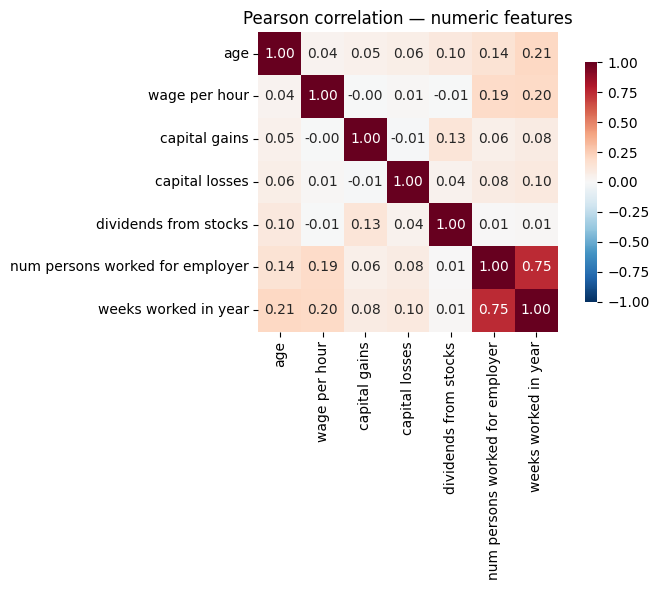

In [15]:
# Numeric feature correlations

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.8},
)
plt.title("Pearson correlation — numeric features")
plt.tight_layout()
plt.show()

In [ ]:
# Examine the 0.75 correlation between weeks worked in year & num persons worked for employer
print("All rows:           ",
      df[["weeks worked in year", "num persons worked for employer"]].corr().iloc[0, 1].round(3))

worked = df[(df["weeks worked in year"] > 0) & (df["num persons worked for employer"] > 0)]
print(f"Workers only ({len(worked):,} rows):",
      worked[["weeks worked in year", "num persons worked for employer"]].corr().iloc[0, 1].round(3))
# Conclusion: high correlation introduced by zero inflation. Non-zero data showed little correlation

All rows:            0.747
Workers only (103,540 rows): 0.079


In [17]:
# Distributions between categorical columns and target
## Low-cardinal columns
cat_cols = [c for c in df.columns if c not in numeric_cols + [weight_col, label_col, "y"]]

def cat_target_table(col, min_count=100):
    g = df.groupby(col).agg(
        n=("y", "size"),
        pos_rate=("y", "mean"),
    ).sort_values("pos_rate", ascending=False)
    return g[g["n"] >= min_count]

base = df["y"].mean()
print(f"Base positive rate: {base:.4f}\n")
for c in cat_cols:
    if df[c].nunique() <= 15:
        print(f"\n=== {c} ===")
        print(cat_target_table(c))

Base positive rate: 0.0621


=== class of worker ===
                                     n  pos_rate
class of worker                                 
Self-employed-incorporated        3265  0.347320
Federal government                2925  0.204103
Self-employed-not incorporated    8445  0.129070
State government                  4227  0.114739
Local government                  7784  0.108813
Private                          72028  0.101655
Not in universe                 100245  0.009018
Without pay                        165  0.006061
Never worked                       439  0.004556

=== enroll in edu inst last wk ===
                                 n  pos_rate
enroll in edu inst last wk                  
Not in universe             186943  0.066074
College or university         5688  0.004395
High school                   6892  0.000725

=== marital stat ===
                                     n  pos_rate
marital stat                                    
Married-civilian spouse pre

In [18]:
## High-cardinal categorical features
for c in cat_cols:
    if df[c].nunique() > 15:
        print(f"\n=== {c}  (nunique={df[c].nunique()}) ===")
        print(cat_target_table(c, min_count=200).head(10))


=== detailed industry recode  (nunique=52) ===
                             n  pos_rate
detailed industry recode                
25                        1084  0.271218
3                          563  0.259325
15                         452  0.254425
49                         610  0.247541
13                         899  0.235818
14                         295  0.233898
45                        4482  0.232932
30                        1181  0.228620
16                         539  0.224490
31                        1178  0.217317

=== detailed occupation recode  (nunique=47) ===
                               n  pos_rate
detailed occupation recode                
7                            731  0.683995
11                           637  0.659341
4                           1364  0.497801
5                            855  0.370760
6                            441  0.349206
2                           8756  0.322179
18                          1083  0.274238
17                     

In [19]:
# During inspection, noticed a significant portion of 0's for these three numeric columns
# Take a look at their distribution against the labels
for c in ["capital gains", "capital losses", "dividends from stocks", "wage per hour"]:
    n_zero = (df[c] == 0).sum()
    print(f"{c}: {n_zero/len(df):.1%} zeros, "
          f"nonzero mean={df.loc[df[c]>0, c].mean():.0f}, "
          f"nonzero pos_rate={df.loc[df[c]>0, 'y'].mean():.3f} "
          f"(base={base:.3f})")

capital gains: 96.3% zeros, nonzero mean=11754, nonzero pos_rate=0.327 (base=0.062)
capital losses: 98.0% zeros, nonzero mean=1906, nonzero pos_rate=0.299 (base=0.062)
dividends from stocks: 89.4% zeros, nonzero mean=1864, nonzero pos_rate=0.251 (base=0.062)
wage per hour: 94.3% zeros, nonzero mean=978, nonzero pos_rate=0.049 (base=0.062)


In [20]:
sample = df.sample(n=min(50_000, len(df)), random_state=SEED)
X_mi = sample[numeric_cols + cat_cols].copy()

# Quick-and-dirty encoding just for MI (not the final encoding)
for c in cat_cols:
    X_mi[c] = X_mi[c].fillna("missing")
X_mi[cat_cols] = OrdinalEncoder().fit_transform(X_mi[cat_cols])
X_mi[numeric_cols] = X_mi[numeric_cols].fillna(X_mi[numeric_cols].median())

mi = mutual_info_classif(X_mi, sample["y"], random_state=SEED)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)
mi_series.to_csv(DATA_DIR / "mi_ranking.csv")
print(mi_series.head(25))
print("\n--- bottom 10 (drop candidates) ---")
print(mi_series.tail(10))

detailed occupation recode                    0.063935
education                                     0.056577
major occupation code                         0.054410
weeks worked in year                          0.041498
detailed industry recode                      0.040712
major industry code                           0.039866
age                                           0.036192
tax filer stat                                0.035549
class of worker                               0.035145
num persons worked for employer               0.033239
detailed household and family stat            0.032712
detailed household summary in household       0.032708
family members under 18                       0.027609
dividends from stocks                         0.026244
capital gains                                 0.024754
veterans benefits                             0.024616
marital stat                                  0.023645
sex                                           0.020106
full or pa

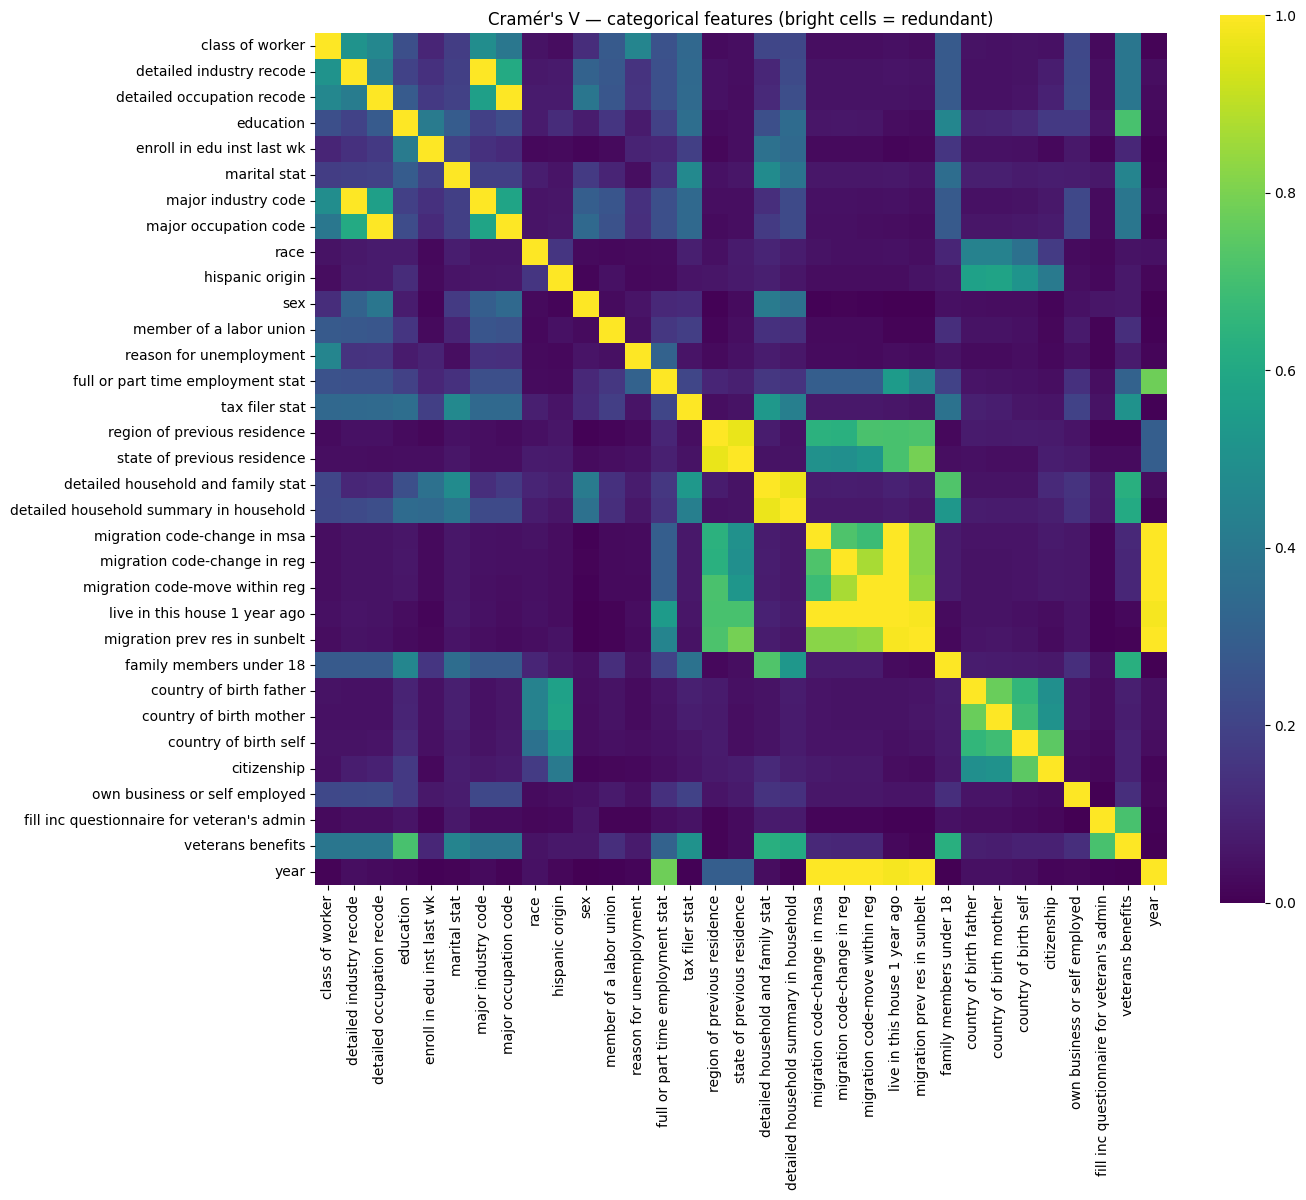

Top 15 redundant categorical pairs (V ≥ 0.5):
migration prev res in sunbelt       year                                       1.000000
migration code-move within reg      year                                       1.000000
migration code-change in reg        year                                       1.000000
migration code-change in msa        year                                       1.000000
detailed occupation recode          major occupation code                      1.000000
migration code-change in msa        live in this house 1 year ago              1.000000
detailed industry recode            major industry code                        1.000000
migration code-move within reg      live in this house 1 year ago              1.000000
migration code-change in reg        live in this house 1 year ago              1.000000
live in this house 1 year ago       migration prev res in sunbelt              0.992127
                                    year                                  

In [21]:
def cramers_v(x, y):
    """Cramér's V for two categorical variables. Range [0, 1]; ≥0.7 ≈ strong redundancy."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

# Sample to keep runtime reasonable — Cramér's V stabilizes well before 50K rows
sample_cat = df[cat_cols].sample(n=min(50_000, len(df)), random_state=SEED)

cv = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for i, a in enumerate(cat_cols):
    cv.loc[a, a] = 1.0
    for b in cat_cols[i+1:]:
        v = cramers_v(sample_cat[a], sample_cat[b])
        cv.loc[a, b] = v
        cv.loc[b, a] = v

plt.figure(figsize=(14, 12))
sns.heatmap(cv.astype(float), cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=True, yticklabels=True)
plt.title("Cramér's V — categorical features (bright cells = redundant)")
plt.tight_layout()
plt.show()

# Surface the redundant pairs explicitly
upper = cv.astype(float).where(np.triu(np.ones(cv.shape), k=1).astype(bool))
high_v = upper.stack().sort_values(ascending=False)
print("Top 15 redundant categorical pairs (V ≥ 0.5):")
print(high_v[high_v >= 0.5].head(15))

In [ ]:
# Noticed a pattern between Year and Migration columns. Examine with below method
migration_cols = [
    "migration code-change in msa",
    "migration code-move within reg",
    "migration code-change in reg",
    "live in this house 1 year ago",
    "migration prev res in sunbelt",
]
for c in migration_cols:
    print(f"\n=== {c} ===")
    print(df.groupby("year")[c].value_counts().unstack(fill_value=0))
    # Conclusion: discrepancy exists likely due to survey/questionnaire difference. Non-significant.  


=== migration code-change in msa ===
migration code-change in msa      ?  Abroad to MSA  Abroad to nonMSA  MSA to MSA  MSA to nonMSA  NonMSA to MSA  NonMSA to nonMSA  Nonmover  Not identifiable  Not in universe
year                                                                                                                                                                         
94                                0            453                73       10601            790            615              2811     82538               430             1516
95                            99696              0                 0           0              0              0                 0         0                 0                0

=== migration code-move within reg ===
migration code-move within reg      ?  Abroad  Different county same state  Different state in Midwest  Different state in Northeast  Different state in South  Different state in West  Nonmover  \
year                         